# Hackathon Summit 2026 - O Desafio de 1936 (Literary Digest)

Em 1936 a revista Literary Digest mandou 10 milhões de cartões perguntando em quem a pessoa ia votar
pra presidente dos EUA. Voltaram quase 2,4 milhões de respostas e, com isso, a revista apostou que o
Alf Landon (republicano) ia ganhar de goleada (57% x 43%). So que quem ganhou foi o Franklin Roosevelt,
com 62% dos votos, e a revista quebrou logo depois.

Nesse notebook eu tentei entender por que a pesquisa errou tanto, mesmo tendo quase 2,4 milhões de
respostas, e depois tentei corrigir o erro usando os dados da eleição anterior (1932).

Etapas do notebook:
1. Limpar e organizar os dados da planilha
2. Olhar as proporções de voto e o erro por estado
3. Tentar entender de onde vem o erro (viés)
4. Fazer uma regressão linear pra corrigir a previsão

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl.utils import column_index_from_string  # serve pra transformar "AI" em número de coluna
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# caminho da planilha (o notebook fica dentro da pasta Fase1)
caminho_planilha = Path("../SummitDados/LitDigestFull.xlsx")
if not caminho_planilha.exists():
    caminho_planilha = Path("SummitDados/LitDigestFull.xlsx")

pasta_fase1 = caminho_planilha.resolve().parent.parent / "Fase1"
pasta_figuras = pasta_fase1 / "figuras"
pasta_figuras.mkdir(exist_ok=True)

print(caminho_planilha.resolve())

/Users/pedrocm/Documents/GitHub/Summit2026/SummitDados/LitDigestFull.xlsx


## Etapa 1 - Limpando os dados

A planilha tem uma aba pra cada eleição (1924, 1928, 1932, 1936). Vou usar só 1932 e 1936: 1932
porque foi a última eleição antes do erro (vou usar como "âncora"), e 1936 que é o ano do problema.

Primeiro dei uma olhada em como a planilha vem, sem deixar o pandas adivinhar cabeçalho, pra entender
a bagunça que tem lá.

In [2]:
bruto_1936 = pd.read_excel(caminho_planilha, sheet_name="1936", header=None)
bruto_1932 = pd.read_excel(caminho_planilha, sheet_name="1932", header=None)

print(bruto_1936.shape)
print(bruto_1932.shape)

bruto_1936.head(5)

(52, 56)
(53, 45)


,0,1,2,3,4,5,6,7,8,9,...,46,47,48,49,50,51,52,53,54,55
0,NaN,NaN,Landon (R),How did they vote in 1932?,NaN,NaN,NaN,NaN,NaN,NaN,...,%,Electoral votes,Other,%,Electoral votes,Margin,%,Total votes,State,NaN
1,State,Electoral Vote,Landon,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,NaN,...,0.09,-,1397,0.51,-,202838,73.56,275244,AL,https://en.wikipedia.org/wiki/1936_United_Stat...
2,Alabama,11,3060,1218,1298,3,3,412,126,NaN,...,0.26,-,384,0.31,-,53289,42.92,124163,AZ,NaN
3,Arizona,3,2337,1431,647,18,0,129,112,NaN,...,0.25,-,169,0.09,-,114726,63.94,179423,AR,NaN
4,Arkansas,9,2724,1338,953,7,9,274,143,NaN,...,0.43,-,24284,0.92,-,930405,35.26,2638882,CA,NaN


Reparei alguns problemas:
- o cabeçalho tá espalhado em 2 linhas
- tem um bloco de colunas com os dados da pesquisa (Literary Digest) e outro bloco mais pra frente
  com o resultado real da eleição (Wikipedia) - e esse segundo bloco começa uma linha ANTES do
  primeiro (percebi isso comparando as linhas na mão)
- tem linhas que não são estado (tipo "Totals" e "State Unknown"), e a aba de 1932 ainda tem o
  Distrito de Columbia, que a de 1936 não tem
- os nomes dos estados em 1932 tão em CAIXA ALTA e em 1936 tão normal
- em algumas colunas tem um "-" no lugar de número (acho que é zero, vou confirmar mais pra frente)

Vou tratar cada coisa dessas.

In [3]:
# fui olhando a planilha no Excel e anotando a letra de cada coluna que eu precisava
# (bati com o "Data Dictionary.docx" que veio junto)

colunas_pesquisa_1936 = {
    "estado": "A", "votos_eleitorais": "B",
    "landon": "C", "landon_1932_rep": "D", "landon_1932_dem": "E", "landon_1932_soc": "F",
    "landon_1932_outros": "G", "landon_1932_nao_votou": "H", "landon_1932_nao_indicou": "I",
    "roosevelt": "K", "roosevelt_1932_rep": "L", "roosevelt_1932_dem": "M", "roosevelt_1932_soc": "N",
    "roosevelt_1932_outros": "O", "roosevelt_1932_nao_votou": "P", "roosevelt_1932_nao_indicou": "Q",
    "lemke": "S", "outros_candidatos": "AF", "total_pesquisa": "AG",
}
colunas_real_1936 = {
    "estado": "AI", "roosevelt_real": "AK", "landon_real": "AN", "lemke_real": "AQ", "total_real": "BB",
}
colunas_pesquisa_1932 = {"estado": "A", "hoover": "C", "roosevelt": "J", "outros": "W", "total_pesquisa": "Y"}
colunas_real_1932 = {"estado": "AB", "roosevelt_real": "AD", "hoover_real": "AG", "total_real": "AR"}


def pega_colunas(bruto, linha_inicio, colunas):
    # transforma letra de coluna do Excel (tipo "AI") em número e recorta o pedaço da planilha
    novo = {}
    for nome in colunas:
        letra = colunas[nome]
        idx = column_index_from_string(letra) - 1
        novo[nome] = bruto.iloc[linha_inicio:, idx]
    df = pd.DataFrame(novo)
    df = df.reset_index(drop=True)
    return df


# a pesquisa começa na linha 2, o bloco "real" começa na linha 1 (uma antes)
pesquisa_1936 = pega_colunas(bruto_1936, 2, colunas_pesquisa_1936)
real_1936 = pega_colunas(bruto_1936, 1, colunas_real_1936)
pesquisa_1932 = pega_colunas(bruto_1932, 2, colunas_pesquisa_1932)
real_1932 = pega_colunas(bruto_1932, 1, colunas_real_1932)

print(len(pesquisa_1936), len(real_1936), len(pesquisa_1932), len(real_1932))
pesquisa_1936.head()

50 51 51 52


,estado,votos_eleitorais,landon,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_outros,landon_1932_nao_votou,landon_1932_nao_indicou,roosevelt,roosevelt_1932_rep,roosevelt_1932_dem,roosevelt_1932_soc,roosevelt_1932_outros,roosevelt_1932_nao_votou,roosevelt_1932_nao_indicou,lemke,outros_candidatos,total_pesquisa
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,371,8530,50,1,736,394,68,63,13273
1,Arizona,3,2337,1431,647,18,0,129,112,1975,248,1555,33,0,70,69,104,60,4476
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,228,6655,16,8,373,328,138,70,10540
3,California,22,89516,65360,16200,315,53,3519,4069,77245,15165,53520,1816,63,3578,3103,4977,2197,173935
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,1747,7256,284,13,439,286,579,233,26786


Agora vou tirar as linhas que não são estado e deixar o nome do estado sempre igual (tipo "Alabama",
nunca "ALABAMA").

In [4]:
linhas_pra_tirar = ["State Unknown", "Totals", "Totals:", "Total", "District Of Columbia"]


def limpa_estado(df):
    df = df.copy()
    df["estado"] = df["estado"].astype(str).str.strip().str.title()
    df = df[~df["estado"].isin(linhas_pra_tirar)]
    df = df[df["estado"] != "Nan"]  # sobra alguma linha vazia às vezes
    df = df.reset_index(drop=True)
    return df


pesquisa_1936 = limpa_estado(pesquisa_1936)
real_1936 = limpa_estado(real_1936)
pesquisa_1932 = limpa_estado(pesquisa_1932)
real_1932 = limpa_estado(real_1932)

print(len(pesquisa_1936), len(real_1936), len(pesquisa_1932), len(real_1932))
# tem que dar 48 em todo mundo (os 50 estados de hoje menos Alaska e Havaí, que só entraram depois)

48 48 48 48


Agora os "-" que eu vi na planilha. Vou ver em qual coluna isso acontece e o que significa.

In [5]:
for coluna in real_1936.columns:
    if coluna == "estado":
        continue
    tem_texto = real_1936[coluna].apply(lambda v: isinstance(v, str)).sum()
    if tem_texto > 0:
        print(coluna, "-", tem_texto, "valores com texto")

estados_com_traco = real_1936[real_1936["lemke_real"] == "-"]["estado"].tolist()
print(estados_com_traco)

lemke_real - 11 valores com texto
['California', 'Florida', 'Louisiana', 'Maryland', 'Mississippi', 'Nevada', 'New York', 'Oklahoma', 'South Carolina', 'Vermont', 'West Virginia']


É só na coluna do Lemke (candidato de um partido pequeno, o Union Party). Faz sentido: em alguns
estados ele nem concorreu, então não teve voto nenhum lá - por isso o traço. Vou trocar por 0 (não
por NaN, porque NaN ia bagunçar as somas depois).

In [6]:
def vira_numero(df):
    df = df.copy()
    for coluna in df.columns:
        if coluna == "estado":
            continue
        df[coluna] = df[coluna].replace("-", 0)
        df[coluna] = df[coluna].replace("–", 0)  # tem um traço "comprido" também em algum lugar
        df[coluna] = pd.to_numeric(df[coluna])
        df[coluna] = df[coluna].astype(int)
    return df


pesquisa_1936 = vira_numero(pesquisa_1936)
real_1936 = vira_numero(real_1936)
pesquisa_1932 = vira_numero(pesquisa_1932)
real_1932 = vira_numero(real_1932)

real_1936.dtypes

/var/folders/pr/l9n9y44d3d9c725jn4xd7hn40000gn/T/ipykernel_29834/411708912.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[coluna] = df[coluna].replace("-", 0)


estado            object
roosevelt_real     int64
landon_real        int64
lemke_real         int64
total_real         int64
dtype: object

Agora junto os 4 pedaços numa tabela só, usando o nome do estado como chave.

In [7]:
dados = pesquisa_1936.merge(real_1936, on="estado", how="outer")
dados = dados.merge(pesquisa_1932, on="estado", how="outer", suffixes=("", "_1932"))
dados = dados.merge(real_1932, on="estado", how="outer", suffixes=("", "_1932real"))

print(len(dados))
dados.isna().sum().sum()  # se der 0 é sinal que juntou tudo certo

48


np.int64(0)

In [8]:
# renomeando pra não confundir as colunas de 1932 que vieram com nome repetido
dados = dados.rename(columns={
    "hoover": "hoover_1932", "roosevelt_1932": "roosevelt_ld_1932", "outros": "outros_1932",
    "total_pesquisa_1932": "total_pesquisa_1932",
    "roosevelt_real_1932real": "roosevelt_real_1932", "hoover_real": "hoover_real_1932",
    "total_real_1932real": "total_real_1932",
})
dados = dados.sort_values("estado").reset_index(drop=True)
dados.head()

,estado,votos_eleitorais,landon,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_outros,landon_1932_nao_votou,landon_1932_nao_indicou,roosevelt,...,landon_real,lemke_real,total_real,hoover_1932,roosevelt_ld_1932,outros_1932,total_pesquisa_1932,roosevelt_real_1932,hoover_real_1932,total_real_1932
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,...,35358,551,275244,4272,20161,713,25146,207910,34675,245354
1,Arizona,3,2337,1431,647,18,0,129,112,1975,...,33433,3307,124163,2574,4910,362,7846,79264,36104,118251
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,...,32039,4,179423,3712,16225,458,20395,189602,28467,220562
3,California,22,89516,65360,16200,315,53,3519,4069,77245,...,836431,0,2638882,81834,148832,11310,241976,1324157,847902,2267966
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,...,181267,9962,488684,11950,14304,1978,28232,250877,189617,457696


Antes de seguir, dei uma conferida se os números batem (isso é importante porque se eu errei alguma
coluna na hora de recortar, os totais não vão bater):

In [9]:
# 1) landon + roosevelt + lemke + outros tem que dar o total da pesquisa
soma = dados["landon"] + dados["roosevelt"] + dados["lemke"] + dados["outros_candidatos"]
diferenca = (soma - dados["total_pesquisa"]).abs().sum()
print("diferença nos totais da pesquisa de 1936:", diferenca)

# 2) o mesmo pra 1932
soma_1932 = dados["hoover_1932"] + dados["roosevelt_ld_1932"] + dados["outros_1932"]
diferenca_1932 = (soma_1932 - dados["total_pesquisa_1932"]).abs().sum()
print("diferença nos totais da pesquisa de 1932:", diferenca_1932)

# 3) tem que ter 531 votos eleitorais no total (48 estados, sem contar DC nem Alasca/Havaí)
print("total de votos eleitorais:", dados["votos_eleitorais"].sum())

diferença nos totais da pesquisa de 1936: 0
diferença nos totais da pesquisa de 1932: 0
total de votos eleitorais: 531


In [10]:
dados.to_csv(pasta_fase1 / "dados_limpos.csv", index=False)
print("salvei", len(dados), "linhas e", len(dados.columns), "colunas")

salvei 48 linhas e 30 colunas


## Etapa 2 - Olhando as proporções de voto

Pra comparar pesquisa com resultado real, calculei a % de voto no republicano considerando só
republicano + democrata (não entra Lemke nem os candidatos pequenos). É a mesma conta que o
regulamento usa quando fala em 57% x 43%.

In [11]:
dados["pct_pesquisa_1936"] = dados["landon"] / (dados["landon"] + dados["roosevelt"])
dados["pct_real_1936"] = dados["landon_real"] / (dados["landon_real"] + dados["roosevelt_real"])
dados["pct_pesquisa_1932"] = dados["hoover_1932"] / (dados["hoover_1932"] + dados["roosevelt_ld_1932"])
dados["pct_real_1932"] = dados["hoover_real_1932"] / (dados["hoover_real_1932"] + dados["roosevelt_real_1932"])

# erro = quanto a pesquisa errou, em pontos percentuais (positivo = deu mais republicano do que era real)
dados["erro_1936"] = dados["pct_pesquisa_1936"] - dados["pct_real_1936"]
dados["erro_1932"] = dados["pct_pesquisa_1932"] - dados["pct_real_1932"]

dados[["estado", "pct_pesquisa_1936", "pct_real_1936", "erro_1936"]].head()

,estado,pct_pesquisa_1936,pct_real_1936,erro_1936
0,Alabama,0.232841,0.129283,0.103559
1,Arizona,0.541976,0.278249,0.263727
2,Arkansas,0.263647,0.179185,0.084462
3,California,0.536792,0.321301,0.215492
4,Colorado,0.614037,0.380583,0.233454


In [12]:
# resultado do país inteiro: soma todo mundo e divide (não é a média dos estados, porque estado
# grande tem que pesar mais)
pesquisa_nacional_1936 = dados["landon"].sum() / (dados["landon"].sum() + dados["roosevelt"].sum())
real_nacional_1936 = dados["landon_real"].sum() / (dados["landon_real"].sum() + dados["roosevelt_real"].sum())
pesquisa_nacional_1932 = dados["hoover_1932"].sum() / (dados["hoover_1932"].sum() + dados["roosevelt_ld_1932"].sum())
real_nacional_1932 = dados["hoover_real_1932"].sum() / (dados["hoover_real_1932"].sum() + dados["roosevelt_real_1932"].sum())

print("1932 - pesquisa:", round(pesquisa_nacional_1932 * 100, 1), "% | real:", round(real_nacional_1932 * 100, 1), "%")
print("1936 - pesquisa:", round(pesquisa_nacional_1936 * 100, 1), "% | real:", round(real_nacional_1936 * 100, 1), "%")
print()
print("erro em 1932:", round((pesquisa_nacional_1932 - real_nacional_1932) * 100, 1), "pontos")
print("erro em 1936:", round((pesquisa_nacional_1936 - real_nacional_1936) * 100, 1), "pontos")

1932 - pesquisa: 40.2 % | real: 40.9 %
1936 - pesquisa: 57.1 % | real: 37.5 %

erro em 1932: -0.7 pontos
erro em 1936: 19.6 pontos


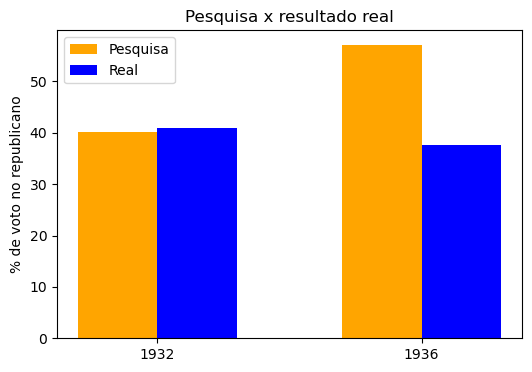

In [13]:
plt.figure(figsize=(6, 4))
x = [0, 1]
plt.bar([p - 0.15 for p in x], [pesquisa_nacional_1932 * 100, pesquisa_nacional_1936 * 100],
        width=0.3, label="Pesquisa", color="orange")
plt.bar([p + 0.15 for p in x], [real_nacional_1932 * 100, real_nacional_1936 * 100],
        width=0.3, label="Real", color="blue")
plt.xticks(x, ["1932", "1936"])
plt.ylabel("% de voto no republicano")
plt.title("Pesquisa x resultado real")
plt.legend()
plt.savefig(pasta_figuras / "fig1_comparacao_nacional.png")
plt.show()

Dá pra ver que em 1932 a pesquisa quase acertou, mas em 1936 ela errou feio. Agora vou olhar
estado por estado pra ver se o erro foi parecido em todo lugar ou se variou muito.

In [14]:
print("média do erro em 1936:", round(dados["erro_1936"].mean() * 100, 1), "pontos")
print("desvio padrão do erro em 1936:", round(dados["erro_1936"].std() * 100, 1), "pontos")
print("erro mínimo:", round(dados["erro_1936"].min() * 100, 1))
print("erro máximo:", round(dados["erro_1936"].max() * 100, 1))

# contando na mão em quantos estados a pesquisa superestimou o Landon (erro positivo)
contador = 0
for erro in dados["erro_1936"]:
    if erro > 0:
        contador = contador + 1
print()
print("em", contador, "de", len(dados), "estados a pesquisa deu mais votos pro Landon do que ele teve de verdade")

média do erro em 1936: 18.6 pontos
desvio padrão do erro em 1936: 7.5 pontos
erro mínimo: 0.6
erro máximo: 32.2

em 48 de 48 estados a pesquisa deu mais votos pro Landon do que ele teve de verdade


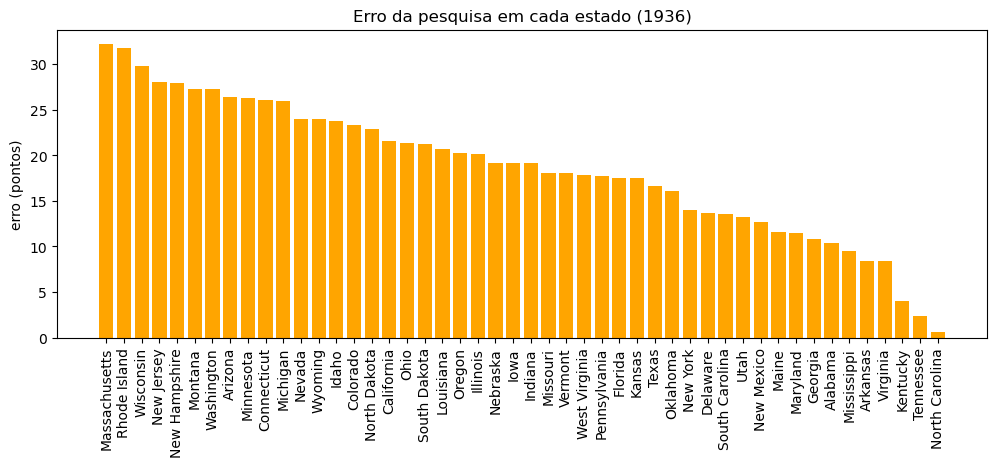

In [15]:
# ordenando do estado que mais errou pro que menos errou
ordenado = dados.sort_values("erro_1936", ascending=False)

plt.figure(figsize=(12, 4))
plt.bar(ordenado["estado"], ordenado["erro_1936"] * 100, color="orange")
plt.xticks(rotation=90)
plt.ylabel("erro (pontos)")
plt.title("Erro da pesquisa em cada estado (1936)")
plt.savefig(pasta_figuras / "fig2_erro_por_estado.png")
plt.show()

O erro foi pra cima em quase todo estado, então não foi coisa de um ou outro estado estranho - foi
um problema sistemático da pesquisa inteira.

## Etapa 3 - Tentando entender o viés

Duas explicações que o pessoal costuma dar pra esse erro:
- **viés de amostragem**: a lista de pessoas que a revista mandou o cartão já era mais rica /
  republicana do que a população em geral (a revista pegava nomes de lista telefônica, de quem
  tinha carro, essas coisas - naquela época isso já filtrava bastante gente pobre)
- **viés de não resposta**: só respondeu quem quis, e talvez quem respondeu pensasse diferente de
  quem não respondeu

A sorte é que a pesquisa de 1936 também perguntou "em quem você votou em 1932?" - e a gente sabe o
resultado real de 1932. Então dá pra comparar: o que os respondentes DISSERAM que votaram em 1932 é
parecido com o que realmente aconteceu em 1932?

In [16]:
# somando quem respondeu que votou em Hoover (republicano) e quem respondeu que votou em
# Roosevelt (democrata) em 1932, entre TODOS que responderam a pesquisa de 1936
rep_1932_lembrado = dados["landon_1932_rep"] + dados["roosevelt_1932_rep"]
dem_1932_lembrado = dados["landon_1932_dem"] + dados["roosevelt_1932_dem"]

dados["pct_lembrado_1932"] = rep_1932_lembrado / (rep_1932_lembrado + dem_1932_lembrado)

# viés = o que a amostra "lembra" que votou menos o que realmente aconteceu
dados["vies_amostra"] = dados["pct_lembrado_1932"] - dados["pct_real_1932"]

nacional_lembrado = rep_1932_lembrado.sum() / (rep_1932_lembrado.sum() + dem_1932_lembrado.sum())
print("amostra de 1936 'lembra' que votou Hoover em 1932:", round(nacional_lembrado * 100, 1), "%")
print("mas o real de 1932 foi:", round(real_nacional_1932 * 100, 1), "%")
print("viés da amostra:", round((nacional_lembrado - real_nacional_1932) * 100, 1), "pontos")

amostra de 1936 'lembra' que votou Hoover em 1932: 52.5 %
mas o real de 1932 foi: 40.9 %
viés da amostra: 11.6 pontos


Então a amostra já vinha puxada pro lado republicano antes mesmo da eleição de 1936 acontecer. Isso
é uma pista forte de viés de amostragem. Vou ver também se o estado que teve amostra mais puxada é o
mesmo estado que teve erro maior em 1936 (fazendo um gráfico de dispersão).

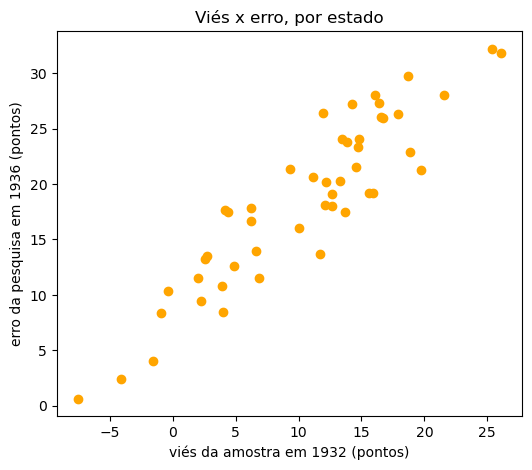

correlação: 0.91


In [17]:
plt.figure(figsize=(6, 5))
plt.scatter(dados["vies_amostra"] * 100, dados["erro_1936"] * 100, color="orange")
plt.xlabel("viés da amostra em 1932 (pontos)")
plt.ylabel("erro da pesquisa em 1936 (pontos)")
plt.title("Viés x erro, por estado")
plt.savefig(pasta_figuras / "fig3_vies_amostragem.png")
plt.show()

correlacao = dados["vies_amostra"].corr(dados["erro_1936"])
print("correlação:", round(correlacao, 2))

A correlação deu bem alta (perto de 1), o que quer dizer que quanto mais puxada pro lado republicano
a amostra do estado, maior foi o erro da pesquisa naquele estado em 1936. Isso reforça que o viés de
amostragem explica boa parte do problema.

Agora vou dar uma olhada rápida na questão da não-resposta também.

In [18]:
# o regulamento diz que foram mandados 10 milhões de cartões
cartoes_enviados = 10_000_000
respondentes = dados["total_pesquisa"].sum()

taxa_resposta = respondentes / cartoes_enviados
print("responderam:", respondentes, "de", cartoes_enviados)
print("taxa de resposta:", round(taxa_resposta * 100, 1), "%")

responderam: 2361960 de 10000000
taxa de resposta: 23.6 %


Só respondeu 1 em cada 4, mais ou menos. Isso sozinho não prova nada, mas é outro fator que pode ter
puxado o resultado pra um lado (quem se dava ao trabalho de responder um cartão-postal em 1936 talvez
não fosse igual à população em geral).

## Etapa 4 - Tentando corrigir com regressão linear

A ideia: como o viés de amostragem de cada estado (calculado com os dados de 1932) tá bem
correlacionado com o erro de 1936, vou treinar uma regressão linear simples pra prever o erro a
partir do viés, e depois usar essa previsão pra corrigir a pesquisa.

Fórmula: `previsão corrigida = pesquisa - erro previsto`

In [19]:
X = dados[["vies_amostra"]]
y = dados["erro_1936"]

modelo = LinearRegression()
modelo.fit(X, y)

print("coeficiente:", modelo.coef_[0])
print("intercepto:", modelo.intercept_)
print("R2 (no próprio treino):", modelo.score(X, y))

coeficiente: 0.9198165032231373
intercepto: 0.08956279191667281
R2 (no próprio treino): 0.8368209482598352


Só que testar o modelo nos mesmos dados que ele treinou não é muito confiável (ele pode estar
"decorando"). Como só tenho 48 linhas (48 estados), usei uma validação chamada leave-one-out: pra
cada estado, treino o modelo com os outros 47 e uso pra prever só aquele que ficou de fora. Assim
repito isso 48 vezes.

In [20]:
loo = LeaveOneOut()
erro_previsto_loo = cross_val_predict(LinearRegression(), X, y, cv=loo)

previsao_corrigida = dados["pct_pesquisa_1936"] - erro_previsto_loo

dados["previsao_corrigida"] = previsao_corrigida
dados.head()

,estado,votos_eleitorais,landon,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_outros,landon_1932_nao_votou,landon_1932_nao_indicou,roosevelt,...,total_real_1932,pct_pesquisa_1936,pct_real_1936,pct_pesquisa_1932,pct_real_1932,erro_1936,erro_1932,pct_lembrado_1932,vies_amostra,previsao_corrigida
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,...,245354,0.232841,0.129283,0.174845,0.142940,0.103559,0.031906,0.139178,-0.003761,0.147966
1,Arizona,3,2337,1431,647,18,0,129,112,1975,...,118251,0.541976,0.278249,0.343934,0.312946,0.263727,0.030987,0.432620,0.119674,0.343753
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,...,220562,0.263647,0.179185,0.186186,0.130541,0.084462,0.055645,0.170700,0.040159,0.135539
3,California,22,89516,65360,16200,315,53,3519,4069,77245,...,2267966,0.536792,0.321301,0.354773,0.390368,0.215492,-0.035595,0.535958,0.145590,0.313091
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,...,457696,0.614037,0.380583,0.455169,0.430464,0.233454,0.024704,0.577345,0.146881,0.389619


In [21]:
# comparando a pesquisa crua com a previsão corrigida, usando 3 métricas + contando os estados certos

mae_bruto = mean_absolute_error(dados["pct_real_1936"], dados["pct_pesquisa_1936"])
mae_corrigido = mean_absolute_error(dados["pct_real_1936"], previsao_corrigida)

rmse_bruto = mean_squared_error(dados["pct_real_1936"], dados["pct_pesquisa_1936"]) ** 0.5
rmse_corrigido = mean_squared_error(dados["pct_real_1936"], previsao_corrigida) ** 0.5

# contando na mão quantos estados o modelo acertou o vencedor
acertos_bruto = 0
acertos_corrigido = 0
for i in range(len(dados)):
    real_venceu_landon = dados["pct_real_1936"].iloc[i] > 0.5
    pesquisa_venceu_landon = dados["pct_pesquisa_1936"].iloc[i] > 0.5
    corrigido_venceu_landon = previsao_corrigida.iloc[i] > 0.5
    if real_venceu_landon == pesquisa_venceu_landon:
        acertos_bruto = acertos_bruto + 1
    if real_venceu_landon == corrigido_venceu_landon:
        acertos_corrigido = acertos_corrigido + 1

print("PESQUISA CRUA")
print("  MAE:", round(mae_bruto * 100, 2), "pontos")
print("  RMSE:", round(rmse_bruto * 100, 2), "pontos")
print("  estados certos:", acertos_bruto, "de", len(dados))
print()
print("PESQUISA CORRIGIDA (com o modelo)")
print("  MAE:", round(mae_corrigido * 100, 2), "pontos")
print("  RMSE:", round(rmse_corrigido * 100, 2), "pontos")
print("  estados certos:", acertos_corrigido, "de", len(dados))

PESQUISA CRUA
  MAE: 18.62 pontos
  RMSE: 20.06 pontos
  estados certos: 18 de 48

PESQUISA CORRIGIDA (com o modelo)
  MAE: 2.63 pontos
  RMSE: 3.12 pontos
  estados certos: 48 de 48


O erro médio caiu bastante depois da correção, e o modelo acertou o vencedor em praticamente todos
os estados (bem melhor do que a pesquisa crua). Vou plotar os dois lado a lado pra ver visualmente.

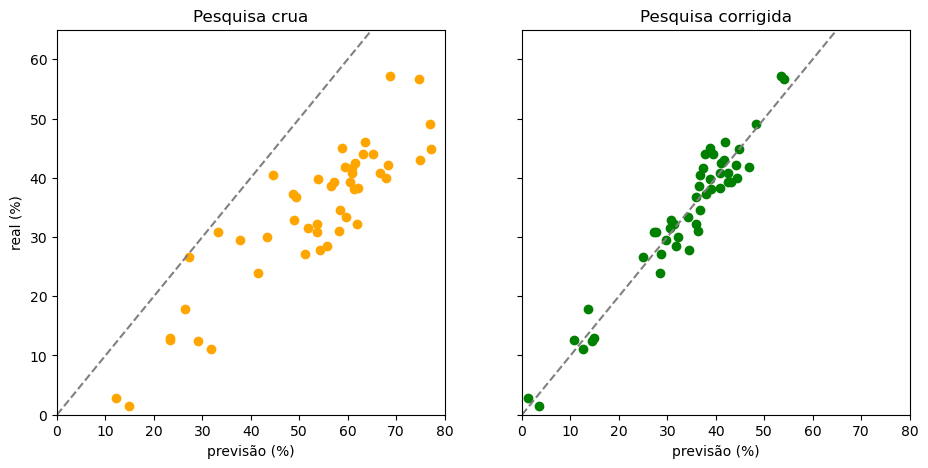

In [22]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

eixos[0].scatter(dados["pct_pesquisa_1936"] * 100, dados["pct_real_1936"] * 100, color="orange")
eixos[0].plot([0, 100], [0, 100], color="gray", linestyle="--")
eixos[0].set_title("Pesquisa crua")
eixos[0].set_xlabel("previsão (%)")
eixos[0].set_ylabel("real (%)")

eixos[1].scatter(previsao_corrigida * 100, dados["pct_real_1936"] * 100, color="green")
eixos[1].plot([0, 100], [0, 100], color="gray", linestyle="--")
eixos[1].set_title("Pesquisa corrigida")
eixos[1].set_xlabel("previsão (%)")

plt.xlim(0, 80)
plt.ylim(0, 65)
plt.savefig(pasta_figuras / "fig5_modelo_antes_depois.png")
plt.show()

Quanto mais perto da linha pontilhada (previsão = real), melhor. Dá pra ver que os pontos verdes
(corrigidos) ficam bem mais perto da linha do que os laranjas (crus).

In [23]:
# quantos votos eleitorais cada versão dava pro Landon
votos_landon_pesquisa = dados.loc[dados["pct_pesquisa_1936"] > 0.5, "votos_eleitorais"].sum()
votos_landon_corrigido = dados.loc[previsao_corrigida > 0.5, "votos_eleitorais"].sum()
votos_landon_real = dados.loc[dados["pct_real_1936"] > 0.5, "votos_eleitorais"].sum()

print("votos eleitorais do Landon segundo a pesquisa crua:", votos_landon_pesquisa)
print("votos eleitorais do Landon segundo a previsão corrigida:", votos_landon_corrigido)
print("votos eleitorais do Landon na vida real:", votos_landon_real)

votos eleitorais do Landon segundo a pesquisa crua: 370
votos eleitorais do Landon segundo a previsão corrigida: 8
votos eleitorais do Landon na vida real: 8


## Conclusão

A pesquisa da Literary Digest não errou por falta de dados (ela teve quase 2,4 milhões de respostas,
o que é MUITA gente). O problema foi que a amostra não representava bem a população: quem respondia
já era mais puxado pro lado republicano, e isso apareceu de forma bem clara quando comparei o que os
respondentes disseram sobre o voto de 1932 com o resultado real daquele ano.

Usando esse viés de 1932 como uma "âncora" pra corrigir a pesquisa de 1936, com uma regressão linear
bem simples, deu pra reduzir bastante o erro e acertar o vencedor em praticamente todos os estados.

Isso tem a ver com IA hoje também: se a base de dados usada pra treinar um modelo não representa bem
a população real (por exemplo, só gente que tem acesso à internet, ou só gente de um certo perfil),
o modelo vai reproduzir esse viés, não importa o quanto de dado ele tenha.

(Limitação: são só 48 observações, e a validação leave-one-out não é bem "prever o futuro" porque o
modelo ainda usa o erro de 1936 dos outros estados pra treinar - então isso mostra que o erro era
explicável, mas não é uma previsão feita de verdade antes da eleição.)